## Дисклеймер!!!!!

Поскольку я терпеть ненавижу отвратно структурированный код, я большую часть инжиринга признаков вынес в отдельный файл. Направление действий будет видно как и указано в задании, но сразу для всего. Я не писал всё одним батчем, тут положена куча коммитов, просто для сохранения ясности я решил не сваливать всё в одну нечитабельную кучу. 

По поводу баллов - претендую на баллы за каждый из указанныз в ДЗ пунктов

## Грузим данные

Из основных фич которые я выделил за это время:

1) Количество добавлений в корзину/поисков/просмотров
2) "Вероятность" добавления в корзину при наличии клика по товару
3) Статистики по количествуй действий за каждую сессию (40 минут)
4) Последние 3/2/1 действия(е)
5) TFIDF + SVD по тексту поиска
6) Флаги на запросы по самым популярным продуктам питания
7) Количество уникальных запросов
8) Статистики по длине запроса в словах/символях (медианная, максимальная, средняя)
9) Последний запрос, его длина в символах и словах
10) Средняя/максимальная/минимальная цена просмотренного товара
11) Доля товаров купленных по скидке
12) Среднее значение скидки
13) Доля наиболее частой категории товаров

+ все признаки которые были в преложенном решении

In [1]:
from data_preparation import OzonDataFormer
from datetime import date

In [2]:
former = OzonDataFormer()

In [3]:
former.fit_text_vectorizer(feature_end_date=date(2024, 5, 31))

In [4]:
train_df = former.construct_dataset(
    feature_end_date=date(2024, 5, 31),
    target_start_date=date(2024, 6, 1),
    target_end_date=date(2024, 6, 30),
    include_actions=True,
    include_search=True,
    include_price=True,
)

In [5]:
val_df = former.construct_dataset(
    feature_end_date=date(2024, 6, 30),
    target_start_date=date(2024, 7, 1),
    target_end_date=date(2024, 7, 31),
    include_actions=True,
    include_search=True,
    include_price=True,
)

In [6]:
X_train = train_df.drop(columns=['user_id', 'target'])
y_train = train_df['target']

In [7]:
X_val = val_df.drop(columns=['user_id', 'target'])
y_val = val_df['target']

In [8]:
from utils2 import AutoFeatureStandardizer

In [9]:
standardizer = AutoFeatureStandardizer()

In [10]:
X_train_s = standardizer.fit_transform(X_train)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [11]:
X_val_s = standardizer.transform(X_val)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

## Проверка адекватности разделения на тренировку и валидацию

In [12]:
cat_features = list(X_train_s.select_dtypes('category').columns) + list(X_train_s.select_dtypes('object').columns)

In [13]:
# embedding_features = ['search_emb']

In [14]:
from catboost.utils import get_gpu_device_count

if get_gpu_device_count() > 0:
    task_type = 'GPU'
else:
    task_type = 'CPU'

params = {
    'iterations': 100,
    'depth': 7,
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': task_type,
    'cat_features': cat_features,
    # 'embedding_features': embedding_features
}

# search_tfidfsvd

In [15]:
# from validation_check import get_train_val_difference

# diff_score, _, _ = get_train_val_difference(X_train, y_train, X_val, y_val, params)

In [16]:
# diff_score

Ну выглядит вроде адекватно учитывая что в данных очевидно есть временная зависимость

## Обучение модели


Скор - 0.81949

In [17]:
from catboost import CatBoostClassifier, Pool

In [18]:
train_pool = Pool(X_train_s, label=y_train, cat_features=cat_features)

val_pool = Pool(X_val_s, label=y_val, cat_features=cat_features)

In [19]:
params['iterations'] = 5000

model = CatBoostClassifier(**params)

In [20]:
try:
    model.load_model('models/weird_shiet.bin')
except Exception:
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )
    model.save_model("models/weird_shiet.bin")

In [21]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

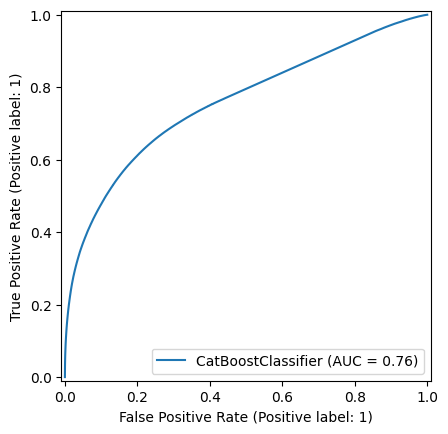

In [22]:
RocCurveDisplay.from_estimator(model, X_val_s, y_val)

## Интерпретация модели

In [23]:
from utils2 import AutoFeatureStandardizer, BinaryClassifierInterpreter
from cluster_compare import NotebookBinaryClusterInterpreter
from bokeh.io import output_notebook

In [24]:
import panel as pn
pn.extension()

Loading BokehJS ...

/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


BokehModel(combine_events=True, render_bundle={'docs_json': {'b56bf7fd-80dc-4d12-887c-03cc4b95911c': {'version…

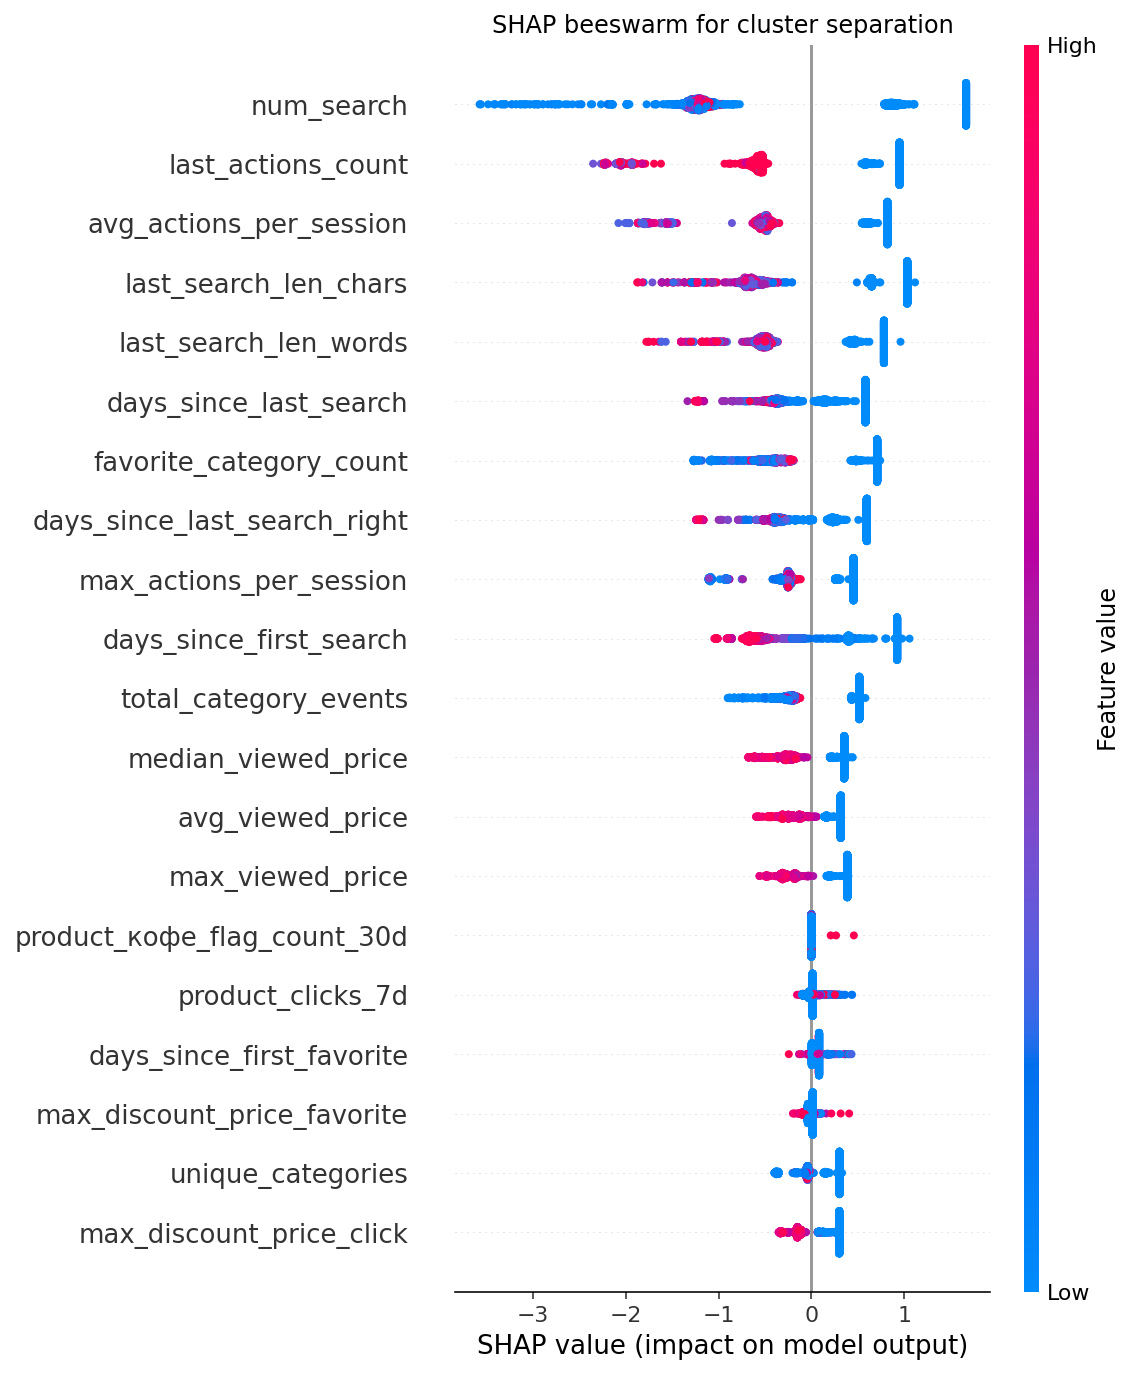

In [ ]:
output_notebook()

tool = NotebookBinaryClusterInterpreter(
    X=X_train_s.loc[::30],
    y=y_train.loc[::30],
)
tool.show()

А выглядит интересно, чётко видны 2 кластер, надо посмотреть чё там такое.

### UPD
Я добавил соотношение меток классов к кластерам, получается интересная картина. Мб имеет смысл использовать результаты кластеризации как признаки для модели, но надо хорошо подумать над алгоритмом кластеризации

### UPD 2
Я добавил SHAP, к сожалению никаких особых откровений. По большому счёту - разделение пользователей по активности.

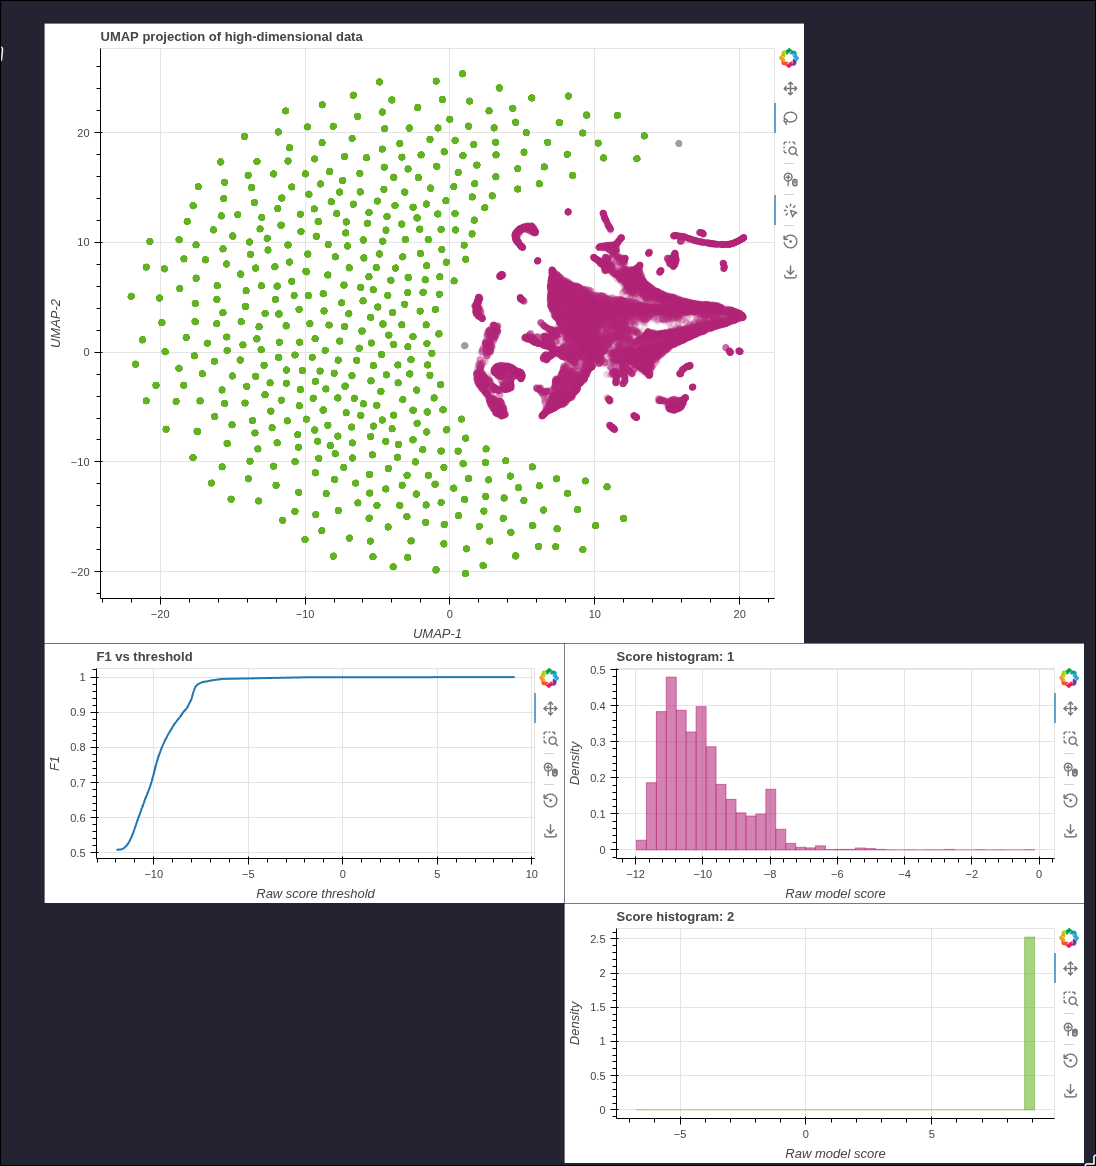

In [26]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train_s[::30], y_train[::30]),
    val=(X_val_s[::10], y_val[::10]),
    model=model
)

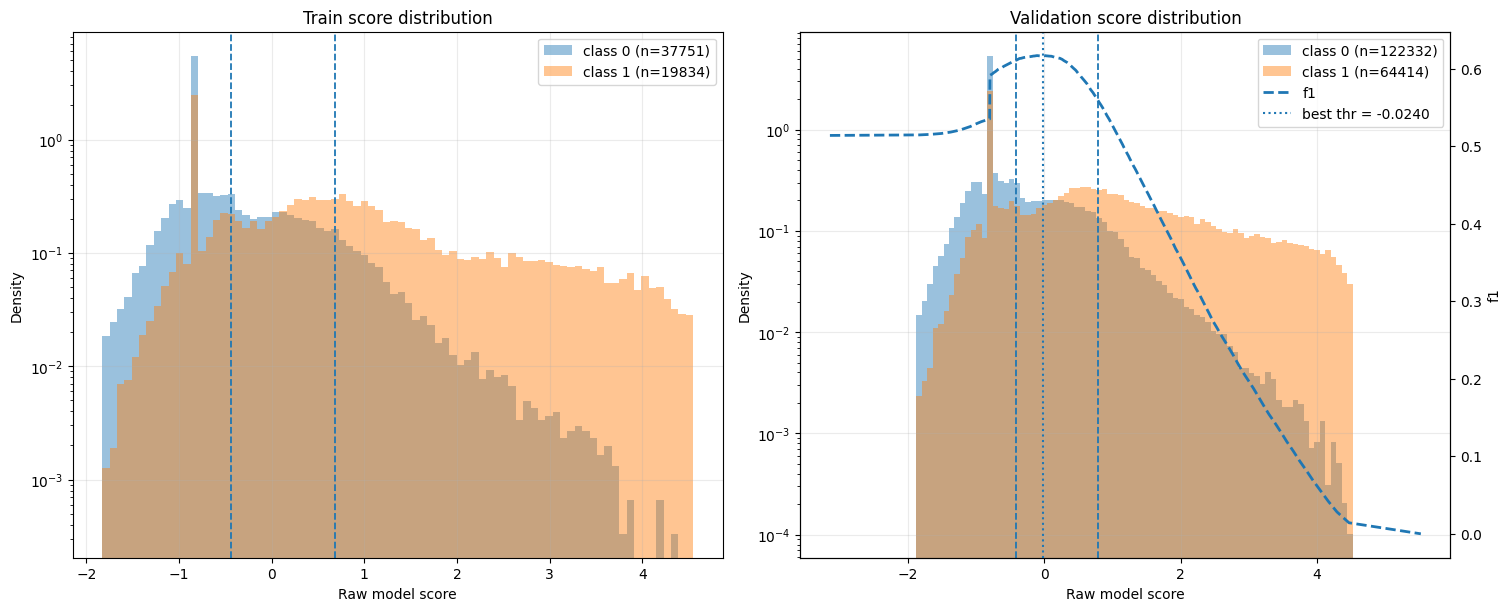

In [32]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

In [28]:
interpreter.plot_float_feature_histograms()

In [29]:
interpreter.plot_score_feature_contours()

In [30]:
interpreter.plot_shap_beeswarm(sample_frac=0.1)

Found a NULL input array in _cext_dense_tree_update_weights!


ExplainerError: Currently TreeExplainer can only handle models with categorical splits when feature_perturbation="tree_path_dependent" and no background data is passed. Please try again using shap.TreeExplainer(model, feature_perturbation="tree_path_dependent").

## Тюнинг параметров


Скор - 0.82092

In [33]:
import optuna
from sklearn.metrics import roc_auc_score

In [34]:
params['iterations'] = 500

In [41]:
def objective(trial: optuna.Trial):
    eta = trial.suggest_float("eta", 1e-3, 10.0, log=True)
    depth = trial.suggest_int("depth", 1, 16)
    
    params['eta'] = eta
    params['depth'] = depth
        
    model = CatBoostClassifier(**params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=False,
        early_stopping_rounds=50,
    )

    preds = model.predict_proba(X_val_s)[:, 1]
    
    score = roc_auc_score(y_val, preds)
    return score


In [42]:
study = optuna.create_study(direction='maximize')

[I 2026-04-13 10:07:37,287] A new study created in memory with name: no-name-0bbedc21-e4f9-4a2a-9be2-91c89f73b67d


In [43]:
study.optimize(objective, n_trials=800)

learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-13 10:07:40,780] Trial 0 finished with value: 0.7332721719345481 and parameters: {'eta': 3.172769980521936, 'depth': 3}. Best is trial 0 with value: 0.7332721719345481.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-13 10:07:48,719] Trial 1 finished with value: 0.7560051144515757 and parameters: {'eta': 0.5903849066033025, 'depth': 6}. Best is trial 1 with value: 0.7560051144515757.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-13 10:07:58,791] Trial 2 finished with value: 0.7384394228572495 and parameters: {'eta': 0.001423496588901

In [44]:
from optuna.visualization import plot_contour
from plotly.io import show

In [45]:
fig = plot_contour(study)

show(fig)

In [46]:
study.best_params

{'eta': 0.055848570897405615, 'depth': 8}

In [47]:
params.update(study.best_params)
params['iterations'] = 5000

## Финальное предсказание

In [48]:
model = CatBoostClassifier(**params).fit(train_pool,
                                         eval_set=val_pool,
                                         use_best_model=True,
                                         verbose=10,
                                         early_stopping_rounds=50)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7468048	best: 0.7468048 (0)	total: 69.8ms	remaining: 5m 48s
10:	test: 0.7523334	best: 0.7523334 (10)	total: 814ms	remaining: 6m 9s
20:	test: 0.7531463	best: 0.7531463 (20)	total: 1.55s	remaining: 6m 8s
30:	test: 0.7538139	best: 0.7538139 (30)	total: 2.32s	remaining: 6m 11s
40:	test: 0.7542796	best: 0.7542796 (40)	total: 3.05s	remaining: 6m 8s
50:	test: 0.7547740	best: 0.7547740 (50)	total: 3.79s	remaining: 6m 7s
60:	test: 0.7551263	best: 0.7551263 (60)	total: 4.54s	remaining: 6m 7s
70:	test: 0.7552898	best: 0.7552898 (70)	total: 5.29s	remaining: 6m 7s
80:	test: 0.7555563	best: 0.7555563 (80)	total: 6.04s	remaining: 6m 6s
90:	test: 0.7557226	best: 0.7557226 (90)	total: 6.77s	remaining: 6m 5s
100:	test: 0.7558889	best: 0.7558889 (100)	total: 7.53s	remaining: 6m 5s
110:	test: 0.7561167	best: 0.7561167 (110)	total: 8.28s	remaining: 6m 4s
120:	test: 0.7562116	best: 0.7562116 (120)	total: 9.03s	remaining: 6m 4s
130:	test: 0.7563485	best: 0.7563485 (130)	total: 9.74s	remaining: 6m 

In [49]:
test_df = former.construct_dataset(
    feature_end_date=date(2024, 7, 31),
    users_df=former.test_users_submission,
    include_actions=True,
    include_search=True,
    include_price=True,
)

In [50]:
X_test = test_df.drop(columns='user_id')

In [51]:
X_test_s = standardizer.transform(X_test)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [52]:
predict = model.predict(X_test_s, prediction_type='Probability')

In [53]:
test_df['predict'] = predict[:, 1]
test_df[['user_id', 'predict']].to_csv('overfitted_ahh.csv', index=False)